# Serial Communication
This example shows how to set up digital_io_2[0-3] and digital_io_3[0-3] as SPI master and UART transmitter, respectively. The internal scopes are used to monitor both interfaces. 

In detail, 4 IO Sync Frames are implemented to showcase the different CPOL and CPHA settings of the SPI interface. The UART interface is used to print log messages and can be read by connecting a USB to UART bridge (FT232) to the corresponding TX and RX lines. See [README](../README.md) for IO Names and Pin Mapping. 

### Imports

In [ ]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.scope import ScopeSource
from redpitaya_io_sync.serial.spi import SPI
from redpitaya_io_sync.serial.uart import UART


### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_2 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_3 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [ ]:
#FRAME 0-3 write UART & SPI (cpha=0-1, cpol=0-1)
for fr, cpol, cpha in zip([fr_0, fr_1, fr_2, fr_3], [0, 0, 1, 1], [0, 1, 0, 1]):
    
    #SPI @ digital_io_2[0-4] and sclk of 122.07kHz
    #Using defaults for sclk_mask= 0b0001, cs_mask= 0b0010, mosi_mask= 0b0100, miso_mask= 0b1000
    spi = SPI(io = fr.digital_io_2, clk_div=1024, cpol=cpol, cpha=cpha) 

    #UART @ digital_io_3[0-1] and baudrate of 115200
    #Using defaults for data_len=8, stop_len=1, parity=None, tx_mask= 0b0001, rx_mask= 0b0010
    uart = UART(io = fr.digital_io_3, baud=115200) 

    fr.reset()
    spi.io_config()
    fr.scope_0.source(ScopeSource.DIGITAL_IO_2)
    fr.scope_0.decimation(100)
    fr.scope_1.source(ScopeSource.DIGITAL_IO_3)
    fr.scope_1.decimation(100)
    fr.rsync()

    fr.scope_0.acquire(200, label="SPI")
    fr.scope_1.acquire(5000, label="UART")
    fr.delay(5000)
    uart.write(data=f"Test UART and SPI with CPOL={cpol} and CPHA={cpha}.\n\r")
    spi.cs_low()
    spi.write(data=0b10110010, size=8)
    spi.cs_high()


### Sequence definition

In [5]:
seq.reset()
for fr, cpol, cpha in zip([fr_0, fr_1, fr_2, fr_3], [0, 0, 1, 1], [0, 1, 0, 1]):
    seq.add_frame(frame=fr, device=rp_0, label=f"UART & SPI (cpol={cpol} cpha={cpha})")

print(seq.sequence_description())

+----------------------------+
| rp_0@192.168.1.143         |
+----------------------------+
| UART & SPI (cpol=0 cpha=0) |
| UART & SPI (cpol=0 cpha=1) |
| UART & SPI (cpol=1 cpha=0) |
| UART & SPI (cpol=1 cpha=1) |
+----------------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [6]:
seq.upload()
seq.start()
while not seq.is_done():
    if seq.is_error():
        print("Sequence error. Please check status.")
        break
    time.sleep(0.01)


In [7]:
seq.get_status()

{'rp_0@192.168.1.143': {'enabled': True,
  'done': True,
  'error': False,
  'current_frame': 'UART & SPI (cpol=1 cpha=1)',
  'io': {'rf_out_0': {'error': False, 'done': True},
   'rf_out_1': {'error': False, 'done': True},
   'digital_io_0': {'error': False, 'done': True},
   'digital_io_1': {'error': False, 'done': True},
   'digital_io_2': {'error': False, 'done': True},
   'digital_io_3': {'error': False, 'done': True},
   'analog_out_0': {'error': False, 'done': True},
   'analog_out_1': {'error': False, 'done': True},
   'analog_out_2': {'error': False, 'done': True},
   'analog_out_3': {'error': False, 'done': True},
   'scope_0': {'error': False, 'done': True},
   'scope_1': {'error': False, 'done': True},
   'led': {'error': False, 'done': True}}}}

In [8]:
# seq.stop()

### Plot acquisitions

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=0 cpha=0)
Scope: scope_0
Label: SPI
Time: 2
Decimation: 100
Samples: 200
Source: DIGITAL_IO_2


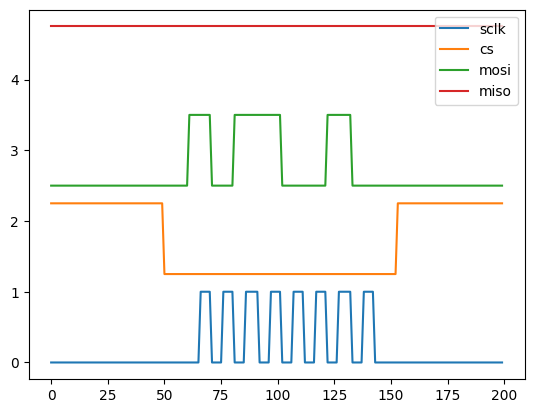

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=0 cpha=0)
Scope: scope_1
Label: UART
Time: 2
Decimation: 100
Samples: 5000
Source: DIGITAL_IO_3


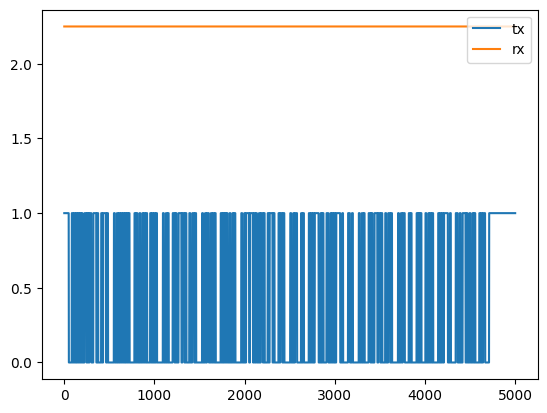

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=0 cpha=1)
Scope: scope_0
Label: SPI
Time: 2
Decimation: 100
Samples: 200
Source: DIGITAL_IO_2


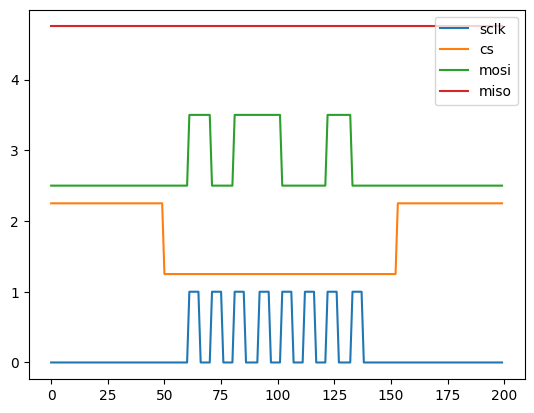

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=0 cpha=1)
Scope: scope_1
Label: UART
Time: 2
Decimation: 100
Samples: 5000
Source: DIGITAL_IO_3


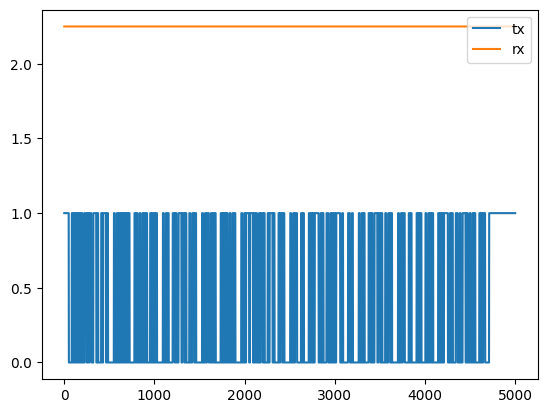

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=1 cpha=0)
Scope: scope_0
Label: SPI
Time: 2
Decimation: 100
Samples: 200
Source: DIGITAL_IO_2


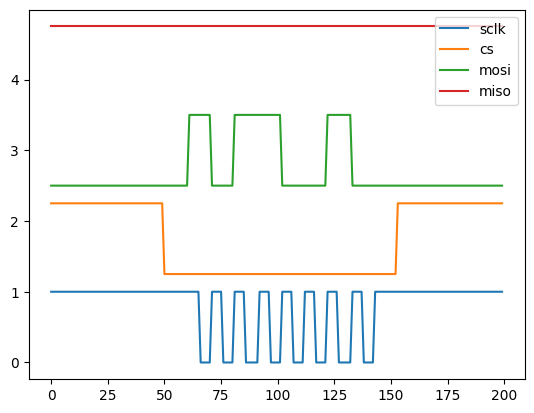

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=1 cpha=0)
Scope: scope_1
Label: UART
Time: 2
Decimation: 100
Samples: 5000
Source: DIGITAL_IO_3


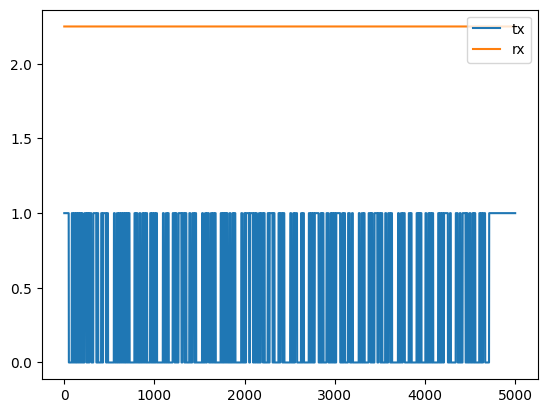

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=1 cpha=1)
Scope: scope_0
Label: SPI
Time: 2
Decimation: 100
Samples: 200
Source: DIGITAL_IO_2


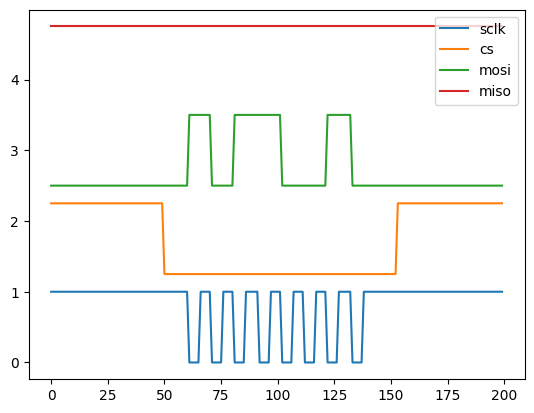

Device: rp_0@192.168.1.143
Frame: UART & SPI (cpol=1 cpha=1)
Scope: scope_1
Label: UART
Time: 2
Decimation: 100
Samples: 5000
Source: DIGITAL_IO_3


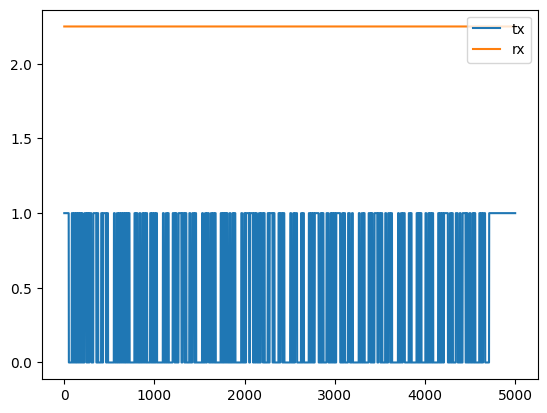

In [9]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                src = scope_dict[device_id][frame_label][scope_label][acq_label]["src"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Scope: {scope_label}")
                print(f"Label: {acq_label}")
                print(f"Time: {t}")
                print(f"Decimation: {dec}")
                print(f"Samples: {samples}")
                print(f"Source: {src}")
                if "SPI" in acq_label:
                    plt.figure()
                    plt.plot(np.bitwise_and(np.right_shift(data, 0), 1), label="sclk")
                    plt.plot(1.25 + np.bitwise_and(np.right_shift(data, 1), 1), label="cs")
                    plt.plot(2.5 + np.bitwise_and(np.right_shift(data, 2), 1), label="mosi")
                    plt.plot(3.75 + np.bitwise_and(np.right_shift(data, 3), 1), label="miso")
                    plt.legend(loc=1)
                    plt.show()
                elif "UART" in acq_label:
                    plt.figure()
                    plt.plot(np.bitwise_and(np.right_shift(data, 0), 1), label="tx")
                    plt.plot(1.25 + np.bitwise_and(np.right_shift(data, 1), 1), label="rx")
                    plt.legend(loc=1)
                    plt.show()